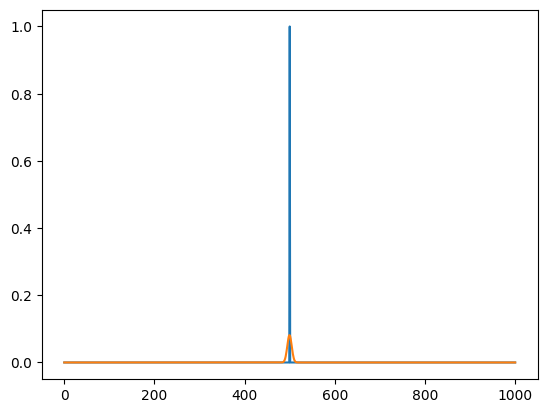

In [93]:
import torch
from torch import nn
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
import torch.nn.functional as F

# torch.manual_seed(0)
# kernel = torch.randn(1, 1, 10).abs()
# give me a gaussian kernel
x = torch.linspace(0, 1, 50)
mu = 0.5
sigma = 0.1
kernel = torch.exp(-0.5 * ((x - mu) / sigma) ** 2)
kernel = kernel / kernel.sum()
# conv1d expects weight shape [out_channels, in_channels, kernel_size]
kernel = kernel.view(1, 1, -1)
# rates = torch.rand(1, 1, 1000)
# conv1d expects input shape [batch, channels, length]
rates = torch.tensor([0.0] * 500 + [1.0] + [0.0] * 500).view(1, 1, -1)

hist = torch.nn.functional.conv1d(rates, kernel, padding="same")

plt.plot(rates.numpy().squeeze())
plt.plot(hist.numpy().squeeze())

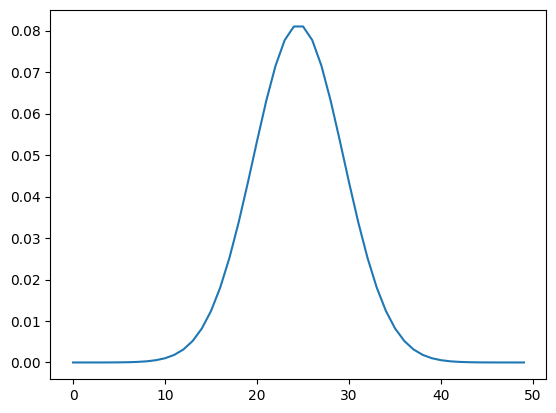

In [94]:
plt.plot(kernel.numpy().squeeze())

In [95]:
def rmse_loss(pred, gt):
    rmse = torch.mean(torch.mean((pred - gt) ** 2, axis=-1) ** 0.5)
    return rmse


def KL_divergence_loss(pred_hist, target_hist):
    p = target_hist / (target_hist.sum(dim=-1, keepdim=True) + 1e-10)
    q = pred_hist / (pred_hist.sum(dim=-1, keepdim=True) + 1e-10)
    # p = target_hist
    # q = pred_hist
    return F.kl_div(q.log(), p, reduction="batchmean")
    # return F.kl_div(F.log_softmax(q, dim=-1), F.softmax(p, dim=-1), reduction="batchmean")


def wasserstein_loss(pred_hist, target_hist):
    p = target_hist / (target_hist.sum(dim=-1, keepdim=True) + 1e-10)
    q = pred_hist / (pred_hist.sum(dim=-1, keepdim=True) + 1e-10)
    # p = target_hist
    # q = pred_hist
    cdf_p = torch.cumsum(p, dim=-1)
    cdf_q = torch.cumsum(q, dim=-1)
    return torch.mean(torch.square(cdf_p - cdf_q))
    # return torch.mean(torch.abs(cdf_p - cdf_q))

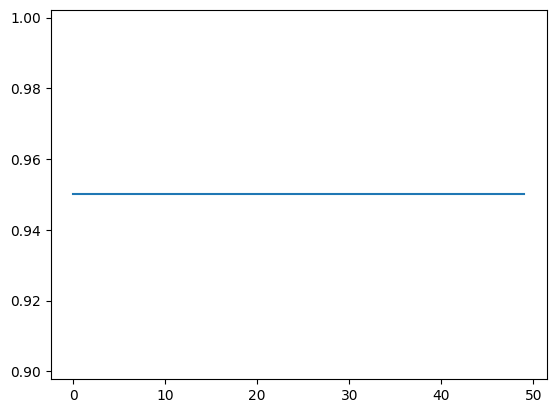

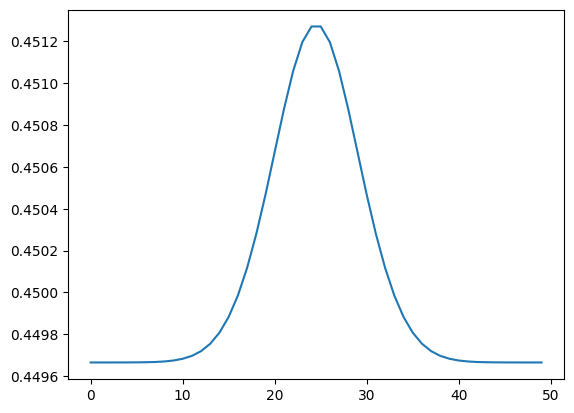

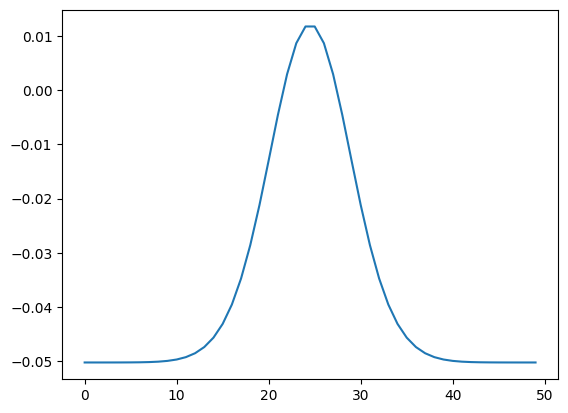

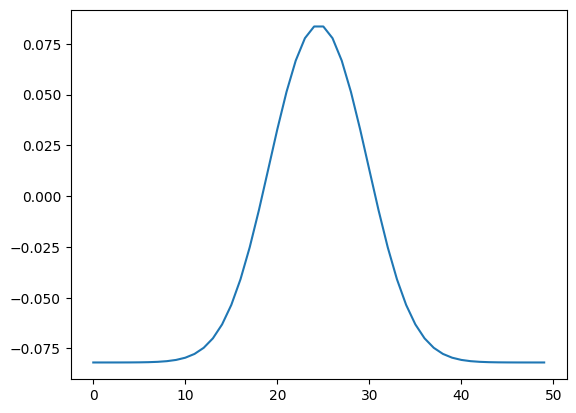

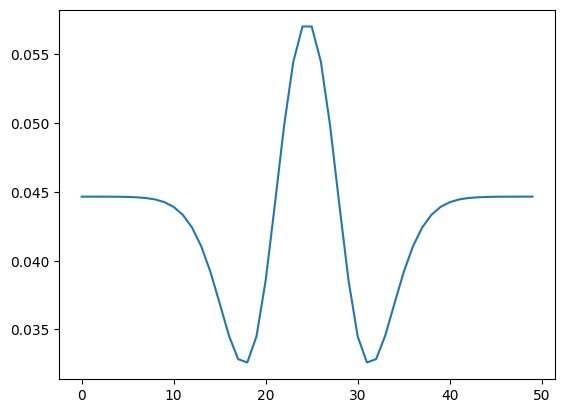

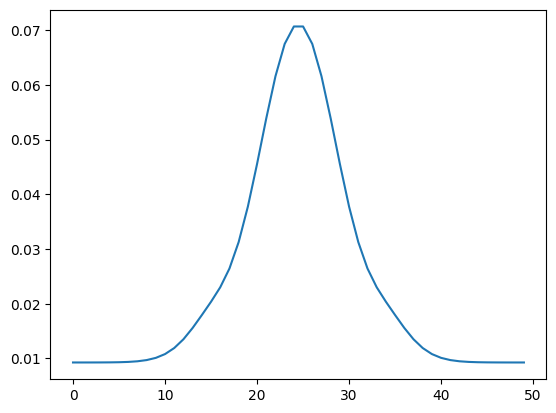

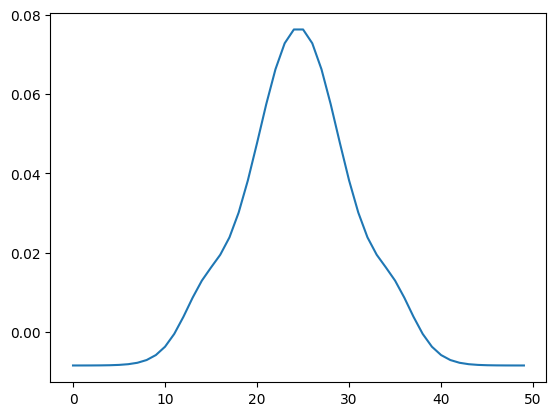

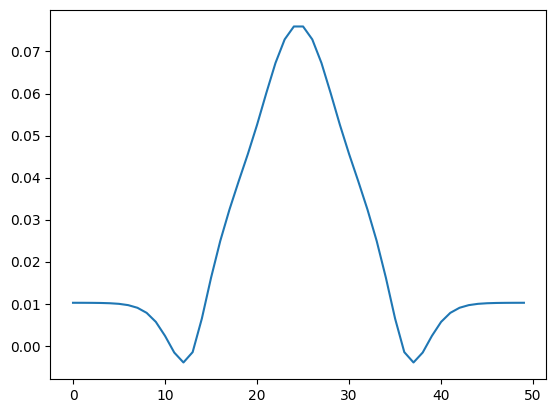

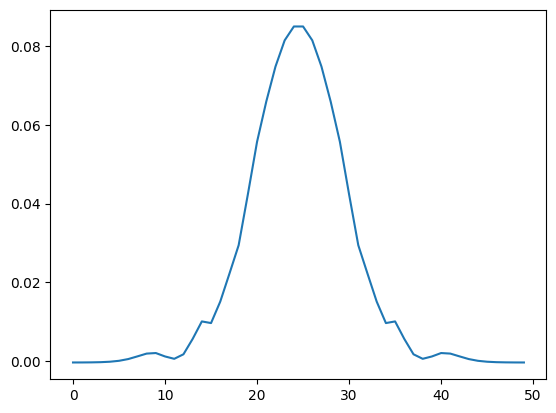

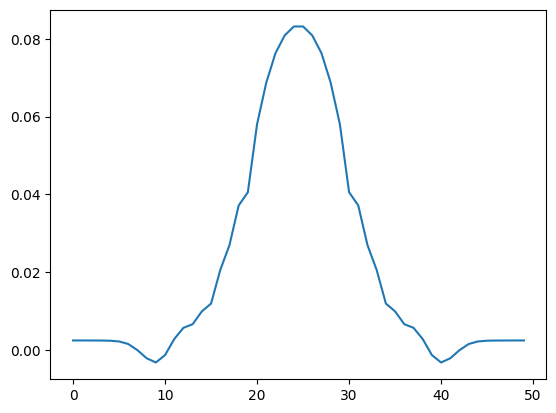

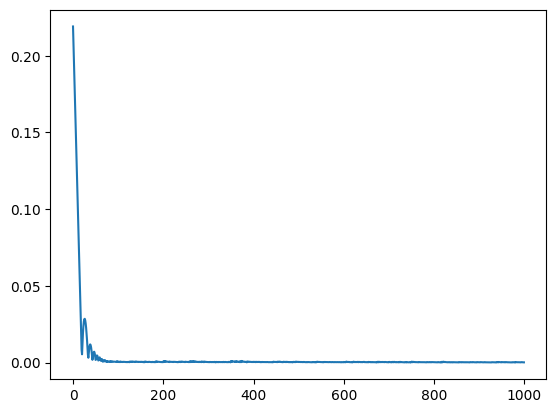

In [96]:
kernel_estimate = nn.Parameter(torch.ones_like(kernel))

optimizer = torch.optim.Adam([kernel_estimate], lr=0.05)
scheduler = lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)
losses = []

for epoch in range(1000):
    optimizer.zero_grad()
    hist_estimate = torch.nn.functional.conv1d(rates, kernel_estimate, padding="same")
    # loss = torch.nn.functional.mse_loss(hist_estimate, hist)
    loss = rmse_loss(hist_estimate, hist)
    # loss = KL_divergence_loss(hist_estimate, hist)
    # loss = wasserstein_loss(hist_estimate, hist)
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())
    # if epoch % 10 == 0:
    if epoch < 100 and epoch % 10 == 0:
        plt.plot(kernel_estimate.detach().numpy().squeeze())
        plt.show()

plt.plot(losses)

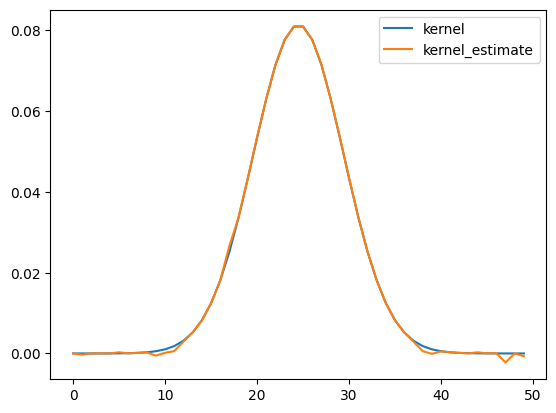

In [97]:
plt.plot(kernel.numpy().squeeze(), label="kernel")
plt.plot(kernel_estimate.detach().numpy().squeeze(), label="kernel_estimate")
plt.legend()
plt.show()